# Pan-Cancer Mallows Clustering Analysis

Evaluates the Tied Bayesian Mallows model run on the pan-cancer gene expression rankings dataset.  
Runs are loaded from `runs_multicluster/` (K = 2–20, mu=1, seed=42).  
Set `K` in the configuration cell below to select which clustering to visualise.

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score

# ── Configuration ─────────────────────────────────────────────────────────────
K    = 20         # number of initial clusters to load (2–20)
MU   = 1
SEED = 42
# ──────────────────────────────────────────────────────────────────────────────

RUN_DIR  = "runs_multicluster"
RUN_FILE = f"{RUN_DIR}/pan_cancer_K{K}_mu{MU}_seed{SEED}.json"
NPZ_FILE = f"{RUN_DIR}/pan_cancer_K{K}_mu{MU}_seed{SEED}.npz"
GE_FILE  = "pan_cancer/gene_expression.csv"
CT_FILE  = "pan_cancer/cancertype.csv"

with open(RUN_FILE) as f:
    run = json.load(f)

npz     = np.load(NPZ_FILE, allow_pickle=True)
z_map   = npz["z_map"]          # (N,) MAP cluster labels
z_trace = npz["z_trace"]        # (n_post_iter, N)

ge = pd.read_csv(GE_FILE, index_col=0)   # (N, n_items) gene expression
ct = pd.read_csv(CT_FILE, index_col=0)   # (N,) cancer type

clusters  = sorted(run["blocks"].keys(), key=int)
theta_map = {k: run["theta_map"][k] for k in clusters}

print(f"N={run['N']}, n_items={run['n_items']}, K_init={run['K_init']}, K_actual={run['K_actual']}")
print(f"n_iter={run['n_iter']}, burn_in={run['burn_in']}, thin={run['thin']}")
print(f"Clusters found: {clusters}")
print(f"z_map unique: {np.unique(z_map)}")
print(f"Gene expression shape: {ge.shape}")

N=2617, n_items=1247, K_init=20, K_actual=6
n_iter=20000, burn_in=5000, thin=1
Clusters found: ['1', '3', '7', '13', '14', '17']
z_map unique: [ 1  3  7 13 14 17]
Gene expression shape: (2617, 1247)


## Cluster Sizes

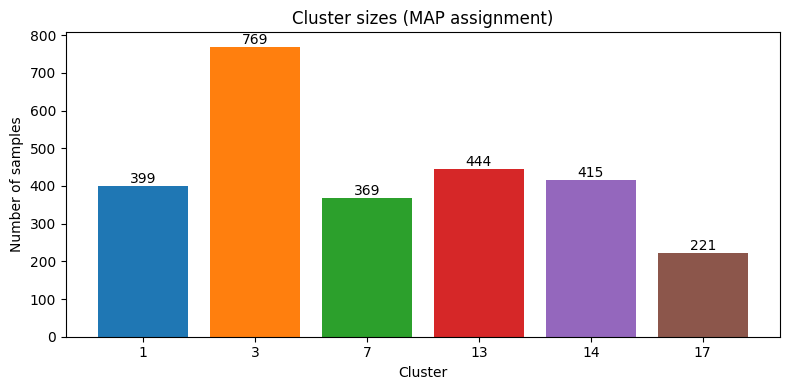

In [10]:
unique_clusters, counts = np.unique(z_map, return_counts=True)
cluster_sizes = pd.Series(counts, index=[str(c) for c in unique_clusters], name="n_samples")

fig, ax = plt.subplots(figsize=(8, 4))
palette = sns.color_palette("tab10", len(clusters))
cluster_color = {c: palette[i] for i, c in enumerate(clusters)}

bars = ax.bar(cluster_sizes.index, cluster_sizes.values,
              color=[cluster_color[c] for c in cluster_sizes.index])
ax.bar_label(bars)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of samples")
ax.set_title("Cluster sizes (MAP assignment)")
plt.tight_layout()
plt.show()

## t-SNE of Gene Expression, Coloured by Cluster and Cancer Type

PCA (50 components) is applied first to reduce the feature space before running t-SNE.

In [6]:
print("Running PCA...")
pca = PCA(n_components=50, random_state=42)
ge_pca = pca.fit_transform(ge.values)
print(f"Explained variance (50 PCs): {pca.explained_variance_ratio_.sum():.2%}")

print("Running t-SNE (this may take ~1 min)...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
tsne_coords = tsne.fit_transform(ge_pca)
print("Done.")

Running PCA...
Explained variance (50 PCs): 75.05%
Running t-SNE (this may take ~1 min)...
Done.


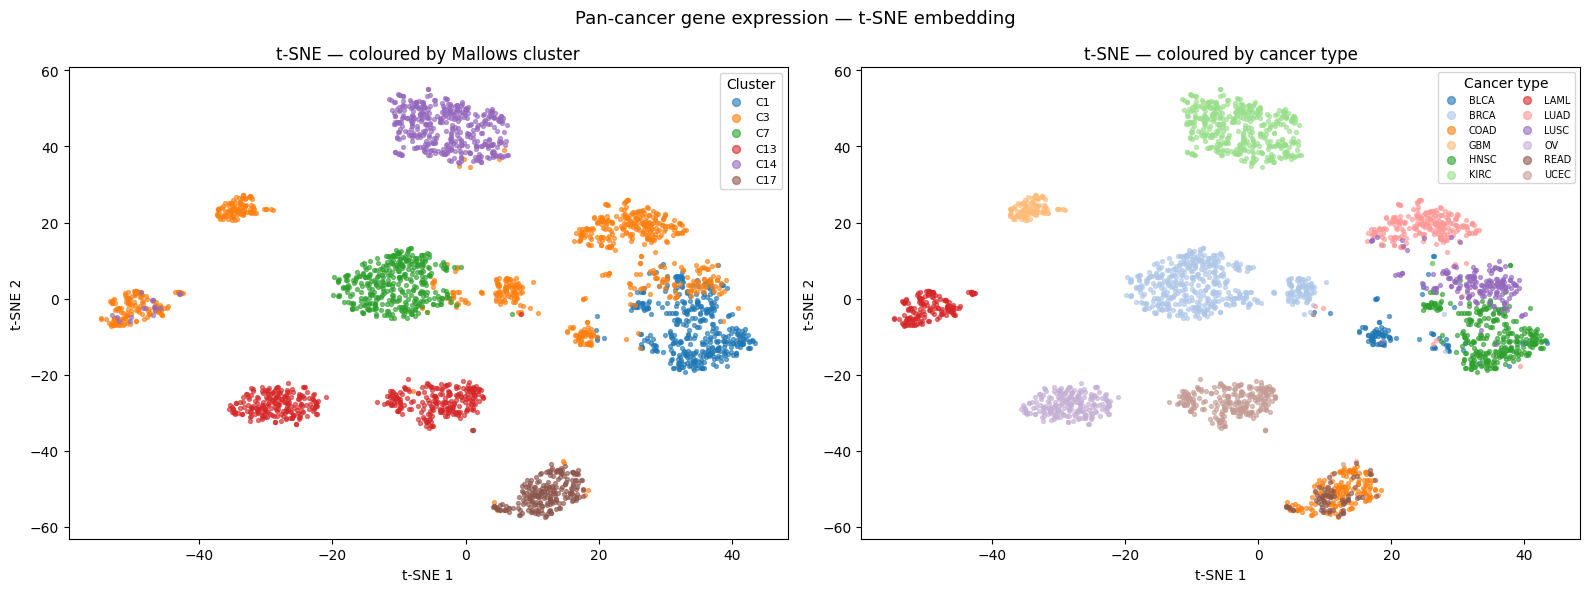

In [11]:
tsne_df = pd.DataFrame({
    "tsne1":   tsne_coords[:, 0],
    "tsne2":   tsne_coords[:, 1],
    "cluster": z_map.astype(str),
    "cancer":  ct["cancertype"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: coloured by cluster ---
ax = axes[0]
for c in clusters:
    mask = tsne_df["cluster"] == c
    ax.scatter(tsne_df.loc[mask, "tsne1"], tsne_df.loc[mask, "tsne2"],
               s=8, alpha=0.6, color=cluster_color[c], label=f"C{c}")
ax.set_title("t-SNE — coloured by Mallows cluster")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=8, title="Cluster")

# --- Panel B: coloured by cancer type ---
ax = axes[1]
cancer_types = sorted(tsne_df["cancer"].unique())
ct_palette   = sns.color_palette("tab20", len(cancer_types))
ct_color     = {t: ct_palette[i] for i, t in enumerate(cancer_types)}
for t in cancer_types:
    mask = tsne_df["cancer"] == t
    ax.scatter(tsne_df.loc[mask, "tsne1"], tsne_df.loc[mask, "tsne2"],
               s=8, alpha=0.6, color=ct_color[t], label=t)
ax.set_title("t-SNE — coloured by cancer type")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=7, title="Cancer type", ncol=2)

plt.suptitle("Pan-cancer gene expression — t-SNE embedding", fontsize=13)
plt.tight_layout()
plt.show()

## Data Thinning: Biological Structure Across Expression and Ranking Spaces

Gaussian thinning splits the expression matrix into two independent halves **X₁** and **X₂**.  
Each half is then rank-transformed per sample to give **R₁** and **R₂** (ordinal ranks 1–1247).

We compute PCA → t-SNE on all four datasets and colour every panel by **cancer type** to assess
whether the biologically meaningful structure is preserved after thinning and after rank transformation.

| Column | Data |
|--------|------|
| X₁ | Thinned expression half 1 |
| X₂ | Thinned expression half 2 |
| R₁ = rank(X₁) | Per-sample gene ranks from half 1 |
| R₂ = rank(X₂) | Per-sample gene ranks from half 2 |


In [ ]:
def gaussian_thin(X, epsilon=0.5, seed=42):
    rng = np.random.default_rng(seed)
    sigma = X.std(axis=0)           # per-gene std
    Z = rng.standard_normal(X.shape)
    X1 = epsilon * X + np.sqrt(epsilon * (1 - epsilon)) * sigma * Z
    X2 = X - X1
    return X1, X2

X1, X2 = gaussian_thin(ge.values)

In [15]:
from scipy.stats import rankdata

def row_ranks(X):
    """Rank genes within each sample (row), returning integer ranks 1..n_items."""
    return np.apply_along_axis(lambda r: rankdata(r, method="average"), axis=1, arr=X)

R1 = row_ranks(X1)
R2 = row_ranks(X2)

datasets = [
    ("X₁ (expression, thin 1)", X1),
    ("X₂ (expression, thin 2)", X2),
    ("R₁ = rank(X₁)",           R1),
    ("R₂ = rank(X₂)",           R2),
]

tsne_results = []
for label, mat in datasets:
    print(f"PCA + t-SNE: {label} ...")
    pca_i = PCA(n_components=50, random_state=42)
    coords_pca = pca_i.fit_transform(mat)
    print(f"  Explained variance (50 PCs): {pca_i.explained_variance_ratio_.sum():.2%}")
    tsne_i = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
    coords_2d = tsne_i.fit_transform(coords_pca)
    tsne_results.append((label, coords_2d))
    print(f"  Done.")


PCA + t-SNE: X₁ (expression, thin 1) ...
  Explained variance (50 PCs): 45.05%
  Done.
PCA + t-SNE: X₂ (expression, thin 2) ...
  Explained variance (50 PCs): 45.13%
  Done.
PCA + t-SNE: R₁ = rank(X₁) ...
  Explained variance (50 PCs): 35.31%
  Done.
PCA + t-SNE: R₂ = rank(X₂) ...
  Explained variance (50 PCs): 35.35%
  Done.


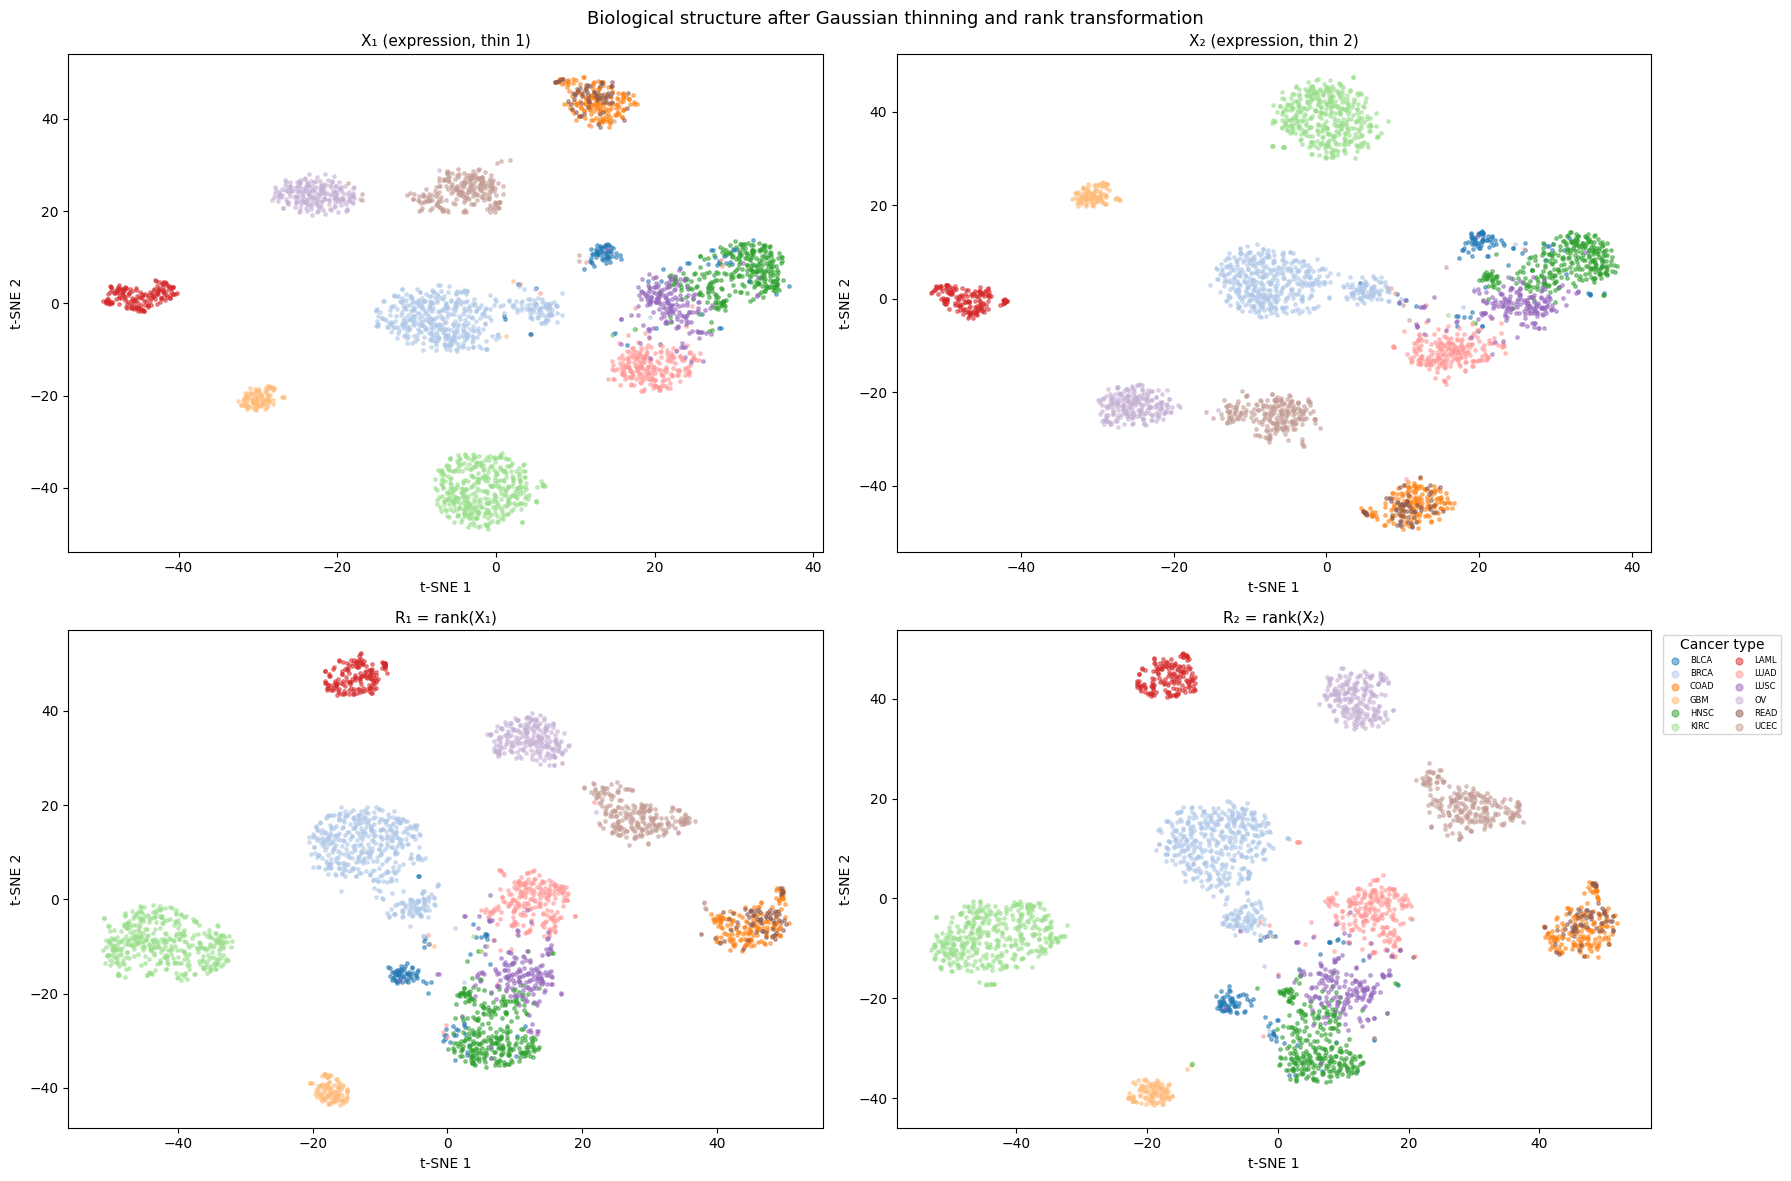

In [16]:
cancer_labels = ct["cancertype"].values

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes_flat = axes.flatten()

for ax, (label, coords) in zip(axes_flat, tsne_results):
    for t in cancer_types:
        mask = cancer_labels == t
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=6, alpha=0.5, color=ct_color[t], label=t)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

# Shared legend on the last panel
axes_flat[-1].legend(markerscale=2, fontsize=6, title="Cancer type", ncol=2,
                     bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Biological structure after Gaussian thinning and rank transformation", fontsize=13)
plt.tight_layout()
plt.show()


## Cluster ↔ Cancer Type Composition

How does each Mallows cluster align with the known cancer types?

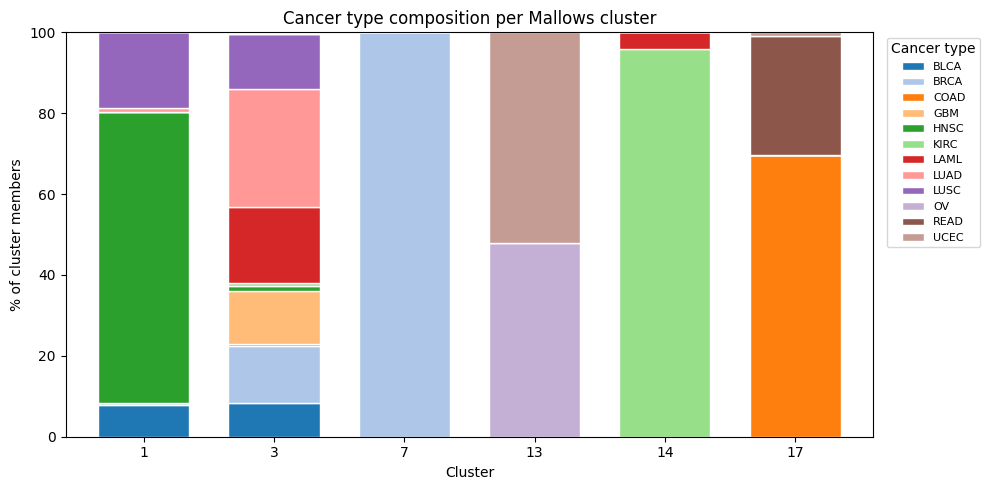

Adjusted Rand Index (cluster vs cancer type): 0.5414


In [17]:
# Cross-tabulation: rows = cancer type, columns = cluster
ct_cluster = pd.crosstab(
    tsne_df["cancer"],
    tsne_df["cluster"].rename("Cluster"),
    normalize="columns"          # fraction within each cluster
) * 100

ct_cluster = ct_cluster[[c for c in clusters if c in ct_cluster.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
ct_cluster.T.plot(kind="bar", stacked=True, ax=ax,
                  color=[ct_color[t] for t in ct_cluster.index],
                  width=0.7, edgecolor="white")
ax.set_xlabel("Cluster")
ax.set_ylabel("% of cluster members")
ax.set_title("Cancer type composition per Mallows cluster")
ax.legend(title="Cancer type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# ARI between MAP cluster and cancer type
ari = adjusted_rand_score(ct["cancertype"].values, z_map)
print(f"Adjusted Rand Index (cluster vs cancer type): {ari:.4f}")

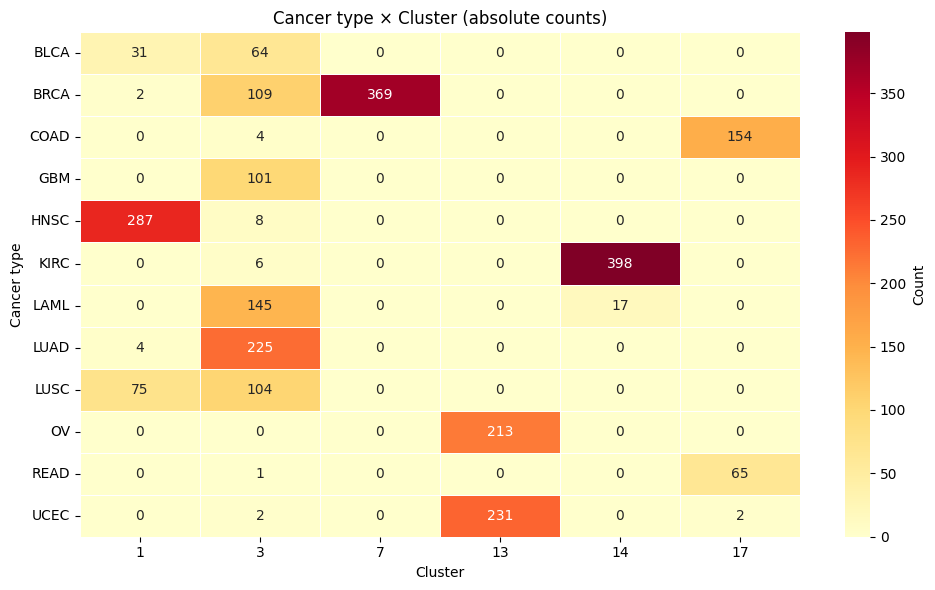

In [17]:
# Heatmap version — absolute counts
ct_counts = pd.crosstab(
    tsne_df["cancer"],
    tsne_df["cluster"].rename("Cluster")
)
ct_counts = ct_counts[[c for c in clusters if c in ct_counts.columns]]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct_counts, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
            ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Cancer type × Cluster (absolute counts)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Cancer type")
plt.tight_layout()
plt.show()

## Concentration Parameters (θ) per Cluster

θ reflects how tightly samples in a cluster agree on the gene ranking. Higher θ = more concentrated / less variation.

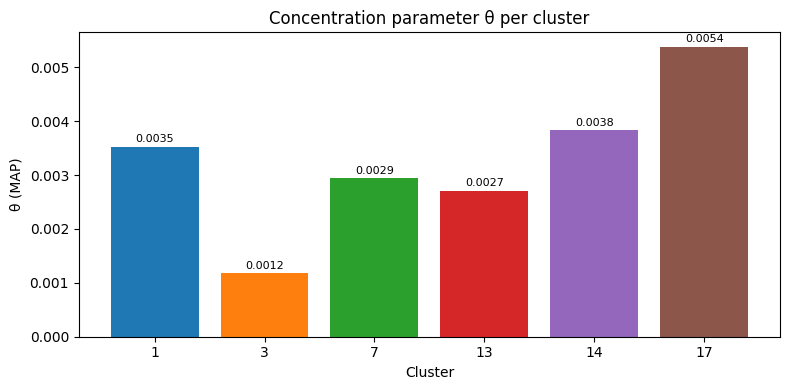

In [18]:
theta_vals = [theta_map[c] for c in clusters]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(clusters, theta_vals,
              color=[cluster_color[c] for c in clusters])
ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
ax.set_xlabel("Cluster")
ax.set_ylabel("θ (MAP)")
ax.set_title("Concentration parameter θ per cluster")
plt.tight_layout()
plt.show()

## Block Structure

In the Tied Mallows model, each cluster has a consensus ranking where genes can be *tied* (placed in the same block).  
A block of size > 1 means those genes share the same rank position in that cluster's consensus.  

Here we visualise:
1. The number and proportion of tied genes per cluster.
2. For clusters with ties: which genes are tied and at which consensus position.

In [20]:
gene_names = ge.columns.tolist()

block_summary = []
for c in clusters:
    blocks = run["blocks"][c]
    sizes  = [len(b) for b in blocks]
    n_tied_genes   = sum(s for s in sizes if s > 1)   # genes in tied blocks
    n_tied_blocks  = sum(1 for s in sizes if s > 1)   # number of tied blocks
    block_summary.append({
        "cluster":        c,
        "n_blocks":       len(blocks),
        "n_tied_blocks":  n_tied_blocks,
        "n_tied_genes":   n_tied_genes,
        "pct_tied_genes": 100.0 * n_tied_genes / run["n_items"],
        "max_block_size": max(sizes),
    })

block_df = pd.DataFrame(block_summary)
print(block_df.to_string(index=False))

cluster  n_blocks  n_tied_blocks  n_tied_genes  pct_tied_genes  max_block_size
      1      1247              0             0         0.00000               1
      3      1247              0             0         0.00000               1
      7      1247              0             0         0.00000               1
     13      1214             32            65         5.21251               3
     14      1247              0             0         0.00000               1
     17      1247              0             0         0.00000               1


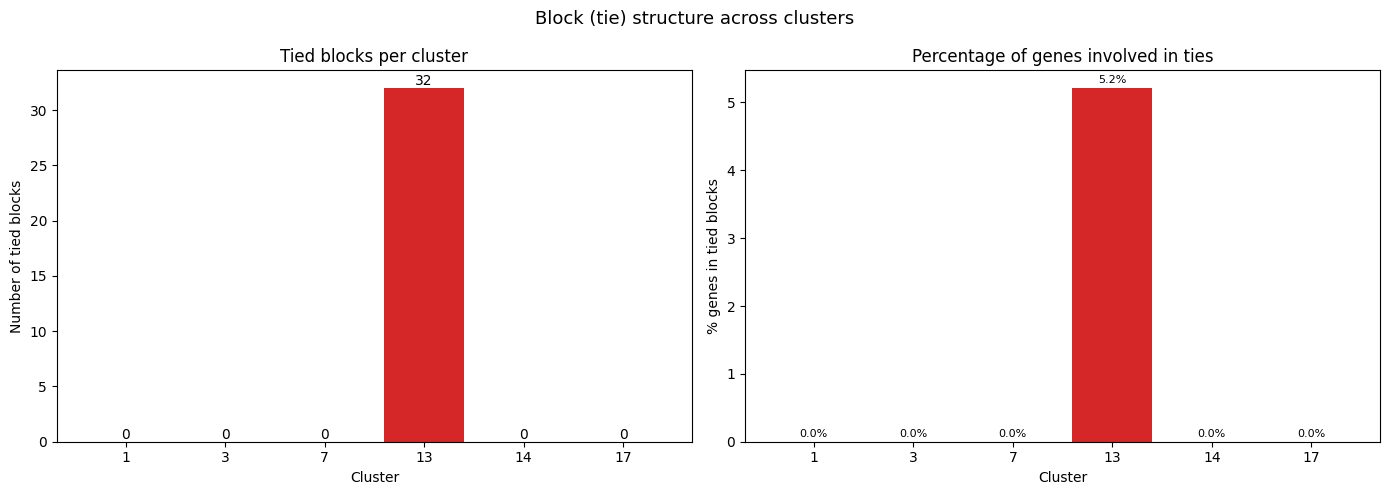

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Number of tied blocks per cluster ---
ax = axes[0]
bars = ax.bar(block_df["cluster"], block_df["n_tied_blocks"],
              color=[cluster_color[c] for c in block_df["cluster"]])
ax.bar_label(bars)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of tied blocks")
ax.set_title("Tied blocks per cluster")

# --- Percentage of genes that are tied ---
ax = axes[1]
bars = ax.bar(block_df["cluster"], block_df["pct_tied_genes"],
              color=[cluster_color[c] for c in block_df["cluster"]])
ax.bar_label(bars, fmt="%.1f%%", fontsize=8, padding=2)
ax.set_xlabel("Cluster")
ax.set_ylabel("% genes in tied blocks")
ax.set_title("Percentage of genes involved in ties")

plt.suptitle("Block (tie) structure across clusters", fontsize=13)
plt.tight_layout()
plt.show()

### Tied Genes per Cluster

For clusters with ties, show which genes appear in tied blocks and their consensus position.

In [11]:
tied_clusters = block_df.loc[block_df["n_tied_blocks"] > 0, "cluster"].tolist()

for c in tied_clusters:
    blocks = run["blocks"][c]
    tied_info = []
    for pos, block in enumerate(blocks):
        if len(block) > 1:
            names = [gene_names[i] for i in block]
            tied_info.append({
                "consensus_position": pos + 1,
                "block_size": len(block),
                "genes": ", ".join(names),
            })
    df_tied = pd.DataFrame(tied_info)
    print(f"\n=== Cluster {c} — {len(tied_info)} tied block(s) ===")
    print(df_tied.to_string(index=False))


=== Cluster 11 — 77 tied block(s) ===
 consensus_position  block_size                genes
                 68           2          BEND5, SYNM
                 69           2           DOCK8, MET
                 78           2        RSPH9, TSPAN4
                 96           2        ENOSF1, PDGFA
                102           2           CCL2, RARB
                127           2         HLA.B, PRKG1
                130           2        PTPRD, TGFBR2
                157           2         ATM, CNTNAP3
                162           2        FAM27C, PDIA5
                192           2         EVI2B, PLIN1
                238           2           CTSD, PVT1
                250           2   MGC21881, SLC25A45
                256           2       LOC90834, SPG7
                264           2          HK3, RNF130
                288           2         HIP1R, SNRPN
                320           2         HDAC10, MDM4
                333           2         FLT3, MARCH1
       

### Block-size Distribution Heatmap

Shows the distribution of block sizes along the consensus ranking (binned into deciles) for each cluster.

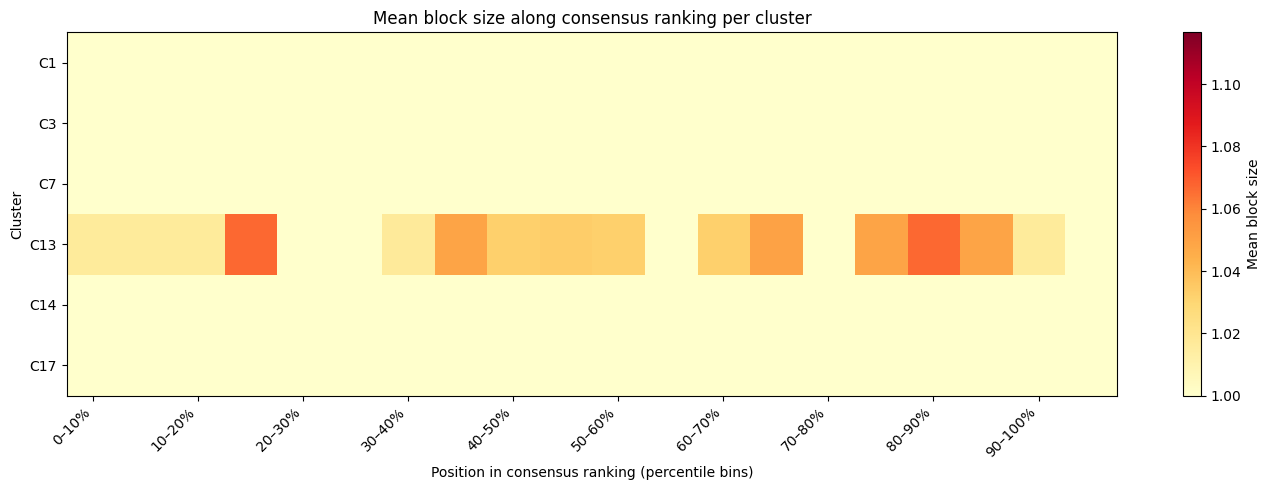

In [22]:
n_bins = 20
n_items = run["n_items"]

# Build a matrix: cluster x bin → mean block size
heatmap_data = np.ones((len(clusters), n_bins))  # default = 1 (no ties)

for ci, c in enumerate(clusters):
    blocks = run["blocks"][c]
    # Assign each block a position index proportional to its place in the consensus
    sizes   = np.array([len(b) for b in blocks])
    # cumulative position of each block's start
    cum_pos = np.arange(len(blocks))  # block index
    bin_idx = np.minimum(
        (cum_pos / len(blocks) * n_bins).astype(int),
        n_bins - 1
    )
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.any():
            heatmap_data[ci, b] = sizes[mask].mean()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, aspect="auto", cmap="YlOrRd",
               vmin=1.0, vmax=heatmap_data.max() + 0.05)
ax.set_yticks(range(len(clusters)))
ax.set_yticklabels([f"C{c}" for c in clusters])
ax.set_xticks(range(0, n_bins, 2))
ax.set_xticklabels([f"{int(100*i/n_bins)}–{int(100*(i+2)/n_bins)}%" for i in range(0, n_bins, 2)],
                   rotation=45, ha="right")
ax.set_xlabel("Position in consensus ranking (percentile bins)")
ax.set_ylabel("Cluster")
ax.set_title("Mean block size along consensus ranking per cluster")
plt.colorbar(im, ax=ax, label="Mean block size")
plt.tight_layout()
plt.show()

## Cluster Assignment Stability

Using the posterior trace of cluster assignments to assess how stable each sample's cluster membership is.

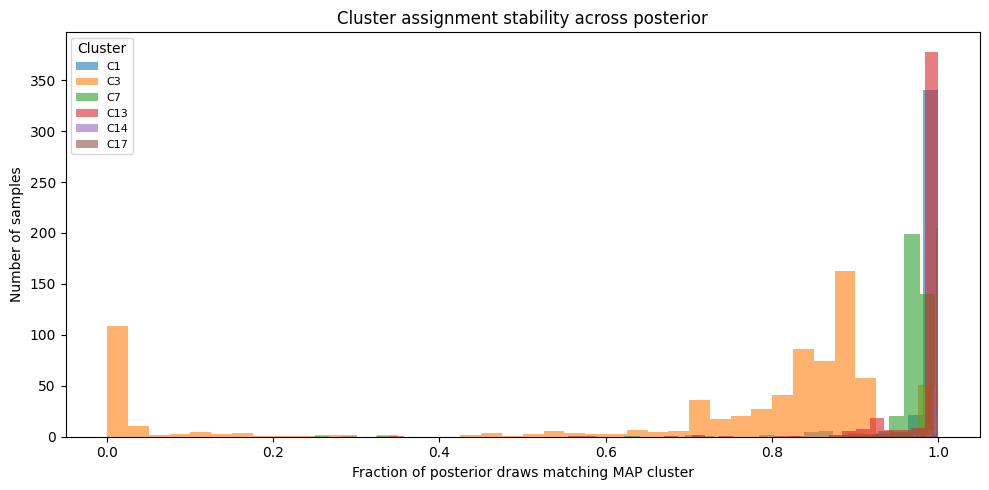


Mean stability per cluster:
cluster
1     0.983648
13    0.982283
14    0.996106
17    0.997922
3     0.689141
7     0.968919


In [23]:
# For each sample, compute the fraction of posterior iterations where it matches its MAP cluster
map_matches = (z_trace == z_map[np.newaxis, :]).mean(axis=0)  # shape (N,)

stab_df = pd.DataFrame({"cluster": z_map.astype(str), "stability": map_matches})

fig, ax = plt.subplots(figsize=(10, 5))
for c in clusters:
    vals = stab_df.loc[stab_df["cluster"] == c, "stability"]
    ax.hist(vals, bins=40, alpha=0.6, color=cluster_color[c], label=f"C{c}")

ax.set_xlabel("Fraction of posterior draws matching MAP cluster")
ax.set_ylabel("Number of samples")
ax.set_title("Cluster assignment stability across posterior")
ax.legend(title="Cluster", fontsize=8)
plt.tight_layout()
plt.show()

print("\nMean stability per cluster:")
print(stab_df.groupby("cluster")["stability"].mean().sort_index().to_string())